<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [10]:
!pip install pandas


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: C:\Users\cubil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
!pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: C:\Users\cubil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [13]:
#file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
#print(df.head())


In [14]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [15]:
duplicate_rows = df.drop_duplicates()


### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [16]:
missing_values_CA = df['CodingActivities'].isnull().value_counts()
print(missing_values_CA)

CodingActivities
False    54466
True     10971
Name: count, dtype: int64


##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [17]:
df['CodingActivities'] = df['CodingActivities'].ffill()
missing_values_CA = df['CodingActivities'].isnull().value_counts()
print(missing_values_CA)

CodingActivities
False    65437
Name: count, dtype: int64


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


In [18]:
missing_CCA = df['ConvertedCompYearly'].isnull().value_counts()
print(missing_CCA)

ConvertedCompYearly
True     42002
False    23435
Name: count, dtype: int64


In [19]:
df_cleaned = df.dropna(subset=['ConvertedCompYearly'])
mean_value = df_cleaned['ConvertedCompYearly'].mean()
print(mean_value)
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(mean_value)
missing_CCA = df['ConvertedCompYearly'].isnull().value_counts()
print(missing_CCA)
print(df[['ConvertedCompYearly']])


86155.28726264134
ConvertedCompYearly
False    65437
Name: count, dtype: int64
       ConvertedCompYearly
0             86155.287263
1             86155.287263
2             86155.287263
3             86155.287263
4             86155.287263
...                    ...
65432         86155.287263
65433         86155.287263
65434         86155.287263
65435         86155.287263
65436         86155.287263

[65437 rows x 1 columns]


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [20]:
compensation_keywords = ['comp', 'salary', 'income', 'pay', 'bonus', 'wage', 'converted']

compensation_columns = df.columns[df.columns.str.contains('|'.join(compensation_keywords), case=False)]
compensation_numeric_columns = [col for col in compensation_columns if pd.api.types.is_numeric_dtype(df[col])]

print("Compensation-related numeric columns:", compensation_numeric_columns)


Compensation-related numeric columns: ['CompTotal', 'ConvertedCompYearly']


##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [21]:
df['ConvertedCompYearly_MinMax'] = (df['ConvertedCompYearly'] - df['ConvertedCompYearly'].min())/(df['ConvertedCompYearly'].max() - df['ConvertedCompYearly'].min())
print(df[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax']].head())

   ConvertedCompYearly  ConvertedCompYearly_MinMax
0         86155.287263                      0.0053
1         86155.287263                      0.0053
2         86155.287263                      0.0053
3         86155.287263                      0.0053
4         86155.287263                      0.0053


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [22]:
df['ConvertedCompYearly_Zscore'] = (df['ConvertedCompYearly'] - df['ConvertedCompYearly'].mean())/(df['ConvertedCompYearly'].std())
print(df[['ConvertedCompYearly', 'ConvertedCompYearly_Zscore']].head())

   ConvertedCompYearly  ConvertedCompYearly_Zscore
0         86155.287263                1.302052e-16
1         86155.287263                1.302052e-16
2         86155.287263                1.302052e-16
3         86155.287263                1.302052e-16
4         86155.287263                1.302052e-16


### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


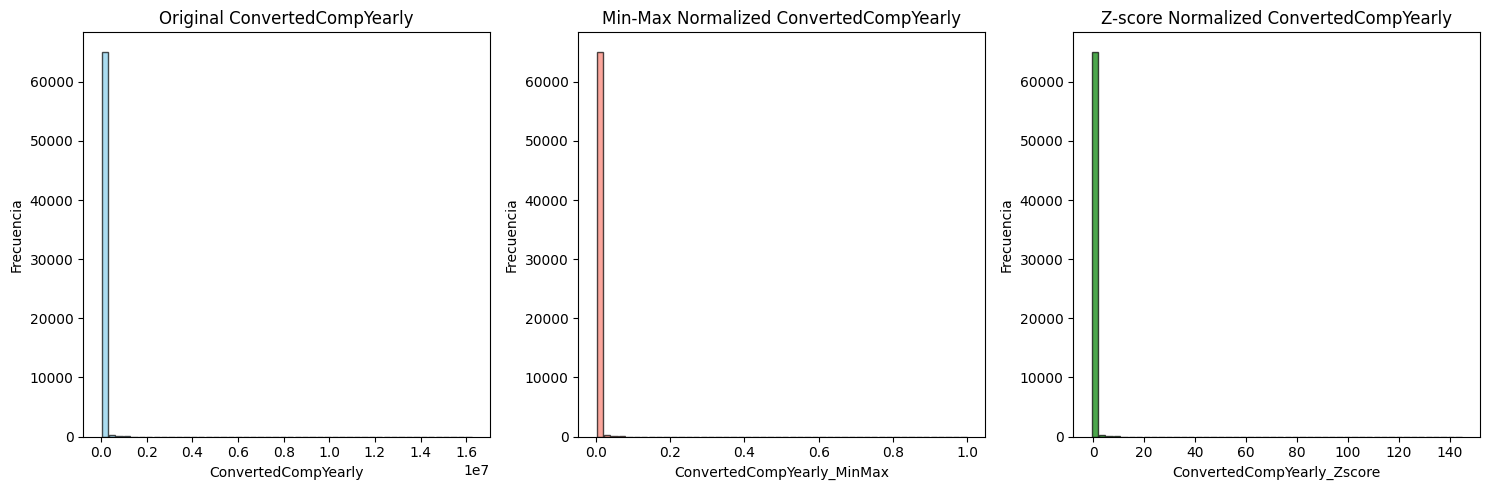

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
plt.hist(df['ConvertedCompYearly'], bins=50, color='skyblue', alpha=0.7, edgecolor='black', rwidth=0.85, )
plt.title('Original ConvertedCompYearly')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 2)
df['ConvertedCompYearly_MinMax'].plot.hist(bins=50, color='salmon', alpha=0.7, edgecolor='black', rwidth=0.85)
plt.title('Min-Max Normalized ConvertedCompYearly')
plt.xlabel('ConvertedCompYearly_MinMax')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 3)
df['ConvertedCompYearly_Zscore'].plot.hist(bins=50, color='green', alpha=0.7, edgecolor='black', rwidth=0.85)
plt.title('Z-score Normalized ConvertedCompYearly')
plt.xlabel('ConvertedCompYearly_Zscore')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
